In [10]:
from pylab import *
import pdb

(257, 3)


C:\Users\DELL\AppData\Local\Temp\ipykernel_19488\2451320068.py:110: RuntimeWarning: invalid value encountered in scalar divide
  s_l = vel_l - sqrt( self.gamma * pre_l / rho_l );
C:\Users\DELL\AppData\Local\Temp\ipykernel_19488\2451320068.py:111: RuntimeWarning: invalid value encountered in scalar divide
  s_r = vel_r - sqrt( self.gamma * pre_r / rho_r );


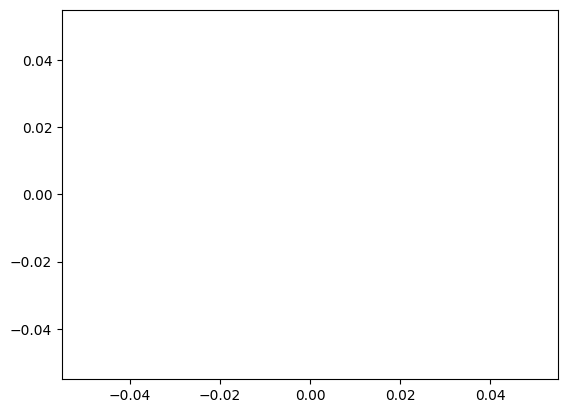

In [ ]:
idx_rho = 0; # density
idx_ene = 1; # energy
idx_mom = 2; # momentum
idx_spe = 5; # chemical species

def minmod( a, b ):
    if a * b < 0:

    return res


def minmod_arr( a, b ):
    res = zeros_like( a );
    for i in range( len( res ) ):
        res[ i ] = minmod( a[i], b[i]);
    return res

class hydro:
    def __init__( self, n_cell, dx, n_int =3, n_gh = 1, gamma = 1.667, CFL = 0.5 ):
        self.u = zeros( (n_cell,            n_int) );
        self.w = zeros( (n_cell + 2 * n_gh, n_int )); # primitive variable
        self.f = zeros( (n_cell + 1       , n_int));
        
        self.n_gh = n_gh;
        self.n_int = n_int;
        self.n_cell = n_cell;
        
        self.dx  = dx;
        self.CFL = CFL;
        self.gamma = gamma;
        self.gam1 = gamma - 1;
        return;
    #
    
    def init( self, rho_l, pre_l, vel_l, rho_r, pre_r, vel_r ):
        i_half = len(self.u) // 2;

        ene_l = pre_l / (self.gamma - 1) + vel_l**2 * rho_l / 2
        ene_r = pre_r / (self.gamma - 1) + vel_r**2 * rho_r / 2
        self.u[ : i_half, idx_rho ] = rho_l;
        self.u[ : i_half, idx_ene ] = ene_l;
        self.u[ : i_half, idx_mom ] = rho_l * vel_l;
        self.u[ i_half : , idx_rho ] = rho_r;
        self.u[ i_half : , idx_ene ] = ene_r;
        self.u[ i_half : , idx_mom ] = rho_r * vel_r;


        return;
    #

    def cons2prim( self ):
        u_T = self.u.T;
        rho = u_T[ idx_rho ];
        mom = u_T[ idx_mom ];
        ene = u_T[ idx_ene ];
        pre = ( ene - mom**2 / (2 * rho)) * (self.gamma - 1);
        vel = mom / rho;
        self.w[ self.n_gh : -self.n_gh, idx_rho ] = rho;
        self.w[ self.n_gh : -self.n_gh, idx_ene ] = pre;
        self.w[ self.n_gh : -self.n_gh, idx_mom ] = vel;

        cs = sqrt( self.gamma * pre / rho );
        self.dt = min(self.CFL * self.dx / (abs(vel) + cs));

        return;
    #


    def set_boundary( self ):
        for i in range( self.n_gh ):
            self.u[ i ]      = self.u[  self.n_gh     ];
            self.u[ -i - 1 ] = self.u[ -self.n_gh - 1 ];
        #
        return;
    #

    def reconstruct( self ):
        self.wl = zeros( self.n_cell + 1 );
        self.wr = zeros( self.n_cell + 1 );
        for i in range( self.n_cell + 1 ):
            wll = self.w[ self.n_gh + i - 2 ];
            wl  = self.w[ self.n_gh + i - 1 ];
            wr  = self.w[ self.n_gh + i ];
            wrr = self.w[ self.n_gh + i + 1 ];
            dwl = ( wl - wll ) / self.dx;
            dwr = ( wrr - wr ) / self.dx;
            dwc = ( wr - wl ) / self.dx;

            self.wl[i] = wl
 
    def reconstruct( self ):
        self.wl = zeros( self.n_cell + 1 );
        self.wr = zeros( self.n_cell + 1 );

        self.wl = self.w[ self.n_gh - 1 : -self.n_gh ];
        if self.n_gh == 1:
            self.wr = self.w[ self.n_gh : ];
        else:
            self.wr = self.w[ self.n_gh : 1 - self.n_gh ];

        return;
    #


    def calc_flux_single( self, w_l, w_r ): # 单一界面
        rho_l = w_l[ idx_rho ];
        pre_l = w_l[ idx_ene ];
        vel_l = w_l[ idx_mom ];
        rho_r = w_r[ idx_rho ];
        pre_r = w_r[ idx_ene ];
        vel_r = w_r[ idx_mom ];
        h_l = pre_l // (self.gamma - 1) * self.gamma;
        h_r = pre_r // (self.gamma - 1) * self.gamma;

        f_rho_l = rho_l * vel_l;
        f_mom_l = rho_l * vel_l**2 +pre_l;
        f_ene_l = (rho_l * vel_l**2 / 2 + h_l) * vel_l;
        f_rho_r = rho_r * vel_r;
        f_mom_r = rho_r * vel_r**2 +pre_r;
        f_ene_r = (rho_r * vel_r**2 / 2 + h_r) * vel_r;

        f_l = zeros( self.n_int );
        f_r = zeros( self.n_int );
        f_l[ idx_rho ] = f_rho_l;
        f_l[ idx_mom ] = f_mom_l;
        f_l[ idx_ene ] = f_ene_l;
        f_r[ idx_rho ] = f_rho_r;
        f_r[ idx_mom ] = f_mom_r;
        f_r[ idx_ene ] = f_ene_r;

        u_l = copy(w_l);
        u_l[ idx_mom ] *= w_l[ idx_rho ];
        u_l[ idx_ene ] = w_l[ idx_ene ] / ( self.gamma - 1 ) + w_l[ idx_rho ] * w_l[ idx_mom ]**2 / 2;
        u_r = copy(w_r);
        u_r[ idx_mom ] *= u_r[ idx_rho ];
        u_r[ idx_ene ] = w_r[ idx_ene ] / ( self.gamma - 1 ) + w_r[ idx_rho ] * w_r[ idx_mom ]**2 / 2;

        s_l = vel_l - sqrt( self.gamma * pre_l / rho_l );
        s_r = vel_r - sqrt( self.gamma * pre_r / rho_r );


        if s_l > 0:
            f = f_l;
        elif s_r < 0:
            f = f_r;
        else:
            
            f = s_r * f_l - s_l * f_r + s_l * s_r * (u_r - u_l);
            f /= s_r - s_l;

        return;
    #


    
    def calc_flux( self ):
        for i in range( len(self.f) ):
            w_l = self.wl[ i ];
            w_r = self.wr[ i ];
            self.f[ i ] = self.calc_flux_single( w_l, w_r );

        return;
    #

    def intg_flux( self ):
        self.u += self.dt / self.dx * ( self.f[ : -1 ] - self.f[ 1 : ] );
        return;
    #



dx = 0.1;
n_cell = 256;
hyd = hydro(n_cell, dx);
hyd.init(1, 2, 0, 0.1, 0.2, 0);

for step in range( 1 ):
    hyd.cons2prim();
    hyd.set_boundary();
    hyd.reconstruct();
    hyd.calc_flux();
    hyd.intg_flux();

plot(hyd.u[ : , idx_mom ])
print(hyd.f.shape)